In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

In [2]:
import os
root_proj = '/Users/luo/OneDrive/GitHub/High-Moutain-Asia-GIS-Data' ### your repo directory
os.chdir(root_proj)

In [3]:
path_hma_holch2019 = 'extents/HMA/hma_bolch2019.gpkg'
path_rivers_global = 'rivers/major_rivers_global.gpkg'

### Note:   
-- Yarlung Zangbo also know as Brahmaputra;   
-- Nu Jiang also know as Salween;   
-- Chang Jiang also know as Yangtze River.


In [17]:
### check data
rivers_global = gpd.read_file(path_rivers_global)
rivers_hma = ['Indus', 'Ganges', 'Yarlung Zangbo', 'Mekong', 'Irrawaddy', 'Huang He', \
              'Syr Darya', 'Amu Darya', 'Chang Jiang', 'Xi Jiang', 'Nu Jiang']
ids = [int(np.where(rivers_global.NAME==name)[0]) for name in rivers_hma]
rivers_hma = rivers_global.loc[ids]
## convert the projection for displaying on the cartopy map.
crs = ccrs.Mercator(); crs_proj4 = crs.proj4_init
rivers_hma_reproj = rivers_hma.geometry.to_crs(crs_proj4)


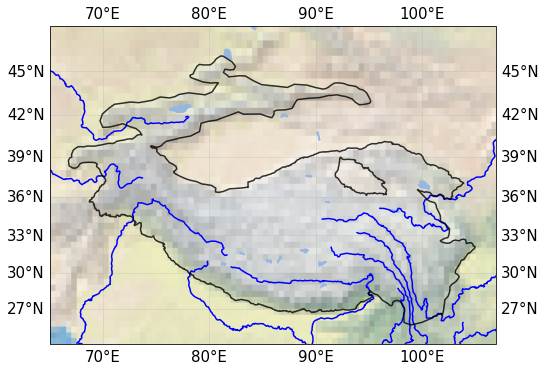

In [18]:
plt.rcParams.update({'font.size':15})
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1,projection=ccrs.Mercator())
ax.set_extent([65.0, 107.0, 24.0, 46.0])
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, zorder=1)
fea_hma_holch2019 = cfeature.ShapelyFeature(Reader(path_hma_holch2019).geometries(),\
                            crs=ccrs.PlateCarree(), edgecolor='Black', alpha=0.8,\
                            linestyle='-', linewidth=1.5, facecolor='none')

rivers_hma_reproj.plot(ax=ax, edgecolor='Blue', linewidth=1.5)
ax.add_feature(fea_hma_holch2019, zorder=2)
ax.stock_img()
ax.add_feature(cfeature.LAKES)
# ax.add_feature(cfeature.RIVERS)
